# Lenovo Battery Capacity Analysis
A time series analysis and forecasting project tracking battery degradation metrics over time. 

### Objectives:
* Clean and standardize raw battery diagnostic data.
* Evaluate temporal properties using ACF and PACF diagnostics.
* Fit an autoregressive forecasting model to predict future capacity loss.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
plt.style.use('ggplot')

## 1. Data Ingestion & Frequency Alignment
Loading raw metrics, correcting data types, stripping formatting artifacts, and standardizing the time-series index to a strict weekly frequency.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset and parse the 'Date' column
df = pd.read_csv('battery_data.csv', parse_dates=['Date'])

# 2. Set the Date column as the index
df.set_index('Date', inplace=True)

# 3. Clean column names by stripping hidden spaces
df.columns = df.columns.str.strip()

# 4. Remove commas from the numbers and convert them from text to integers
df['Charge Capacity'] = df['Charge Capacity'].str.replace(',', '').astype(int)
df['Full Charge Capacity'] = df['Full Charge Capacity'].str.replace(',', '').astype(int)

# 5. Fix time series frequency: drop duplicates, resample to weekly (Mondays), and forward-fill missing data
df = df[~df.index.duplicated(keep='last')]
df_clean = df.resample('W-MON').last().ffill()

# Display the clean structure and the first 5 rows to confirm
df_clean.info()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61 entries, 2025-07-14 to 2026-09-07
Freq: W-MON
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Charge Capacity       61 non-null     float64
 1   Full Charge Capacity  61 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


,Charge Capacity,Full Charge Capacity
Date,,
2025-07-14,58166.0,58000.0
2025-07-21,57937.0,58000.0
2025-07-28,57328.0,58000.0
2025-08-04,56310.0,58000.0
2025-08-11,56450.0,58000.0


In [10]:
# View the data types for the loaded columns
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61 entries, 2025-07-14 to 2026-09-07
Freq: W-MON
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Charge Capacity       61 non-null     float64
 1   Full Charge Capacity  61 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


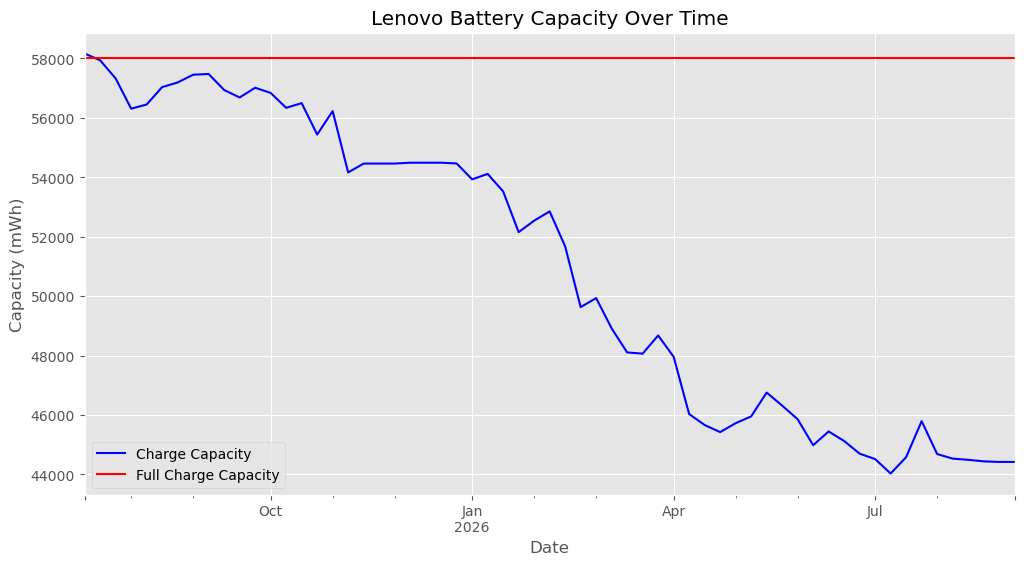

In [11]:
# Plot the battery capacities over time
df_clean.plot(figsize=(12, 6), color=['blue', 'red'])

# Add titles and labels to make it professional
plt.title('Lenovo Battery Capacity Over Time')
plt.xlabel('Date')
plt.ylabel('Capacity (mWh)')

# Show the plot
plt.show()

## 2. Autocorrelation & Stationarity Diagnostics
Examining ACF and PACF plots to identify the underlying stochastic process governing the degradation rate.

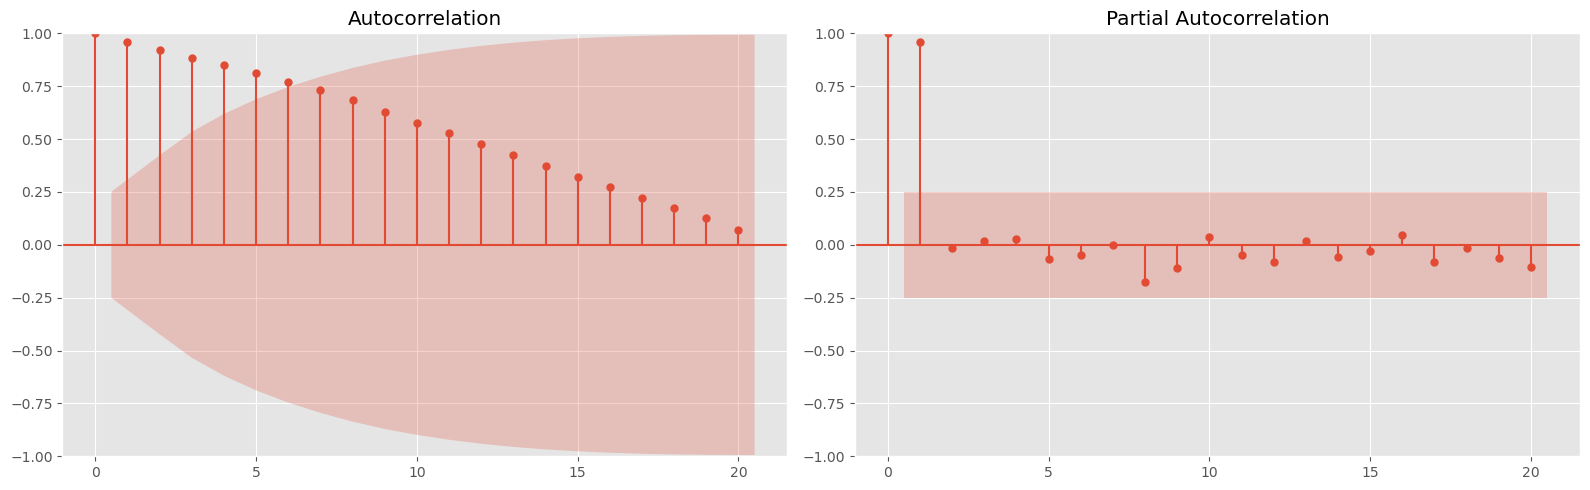

In [12]:
# Create a figure canvas with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plotting the ACF and PACF for Charge Capacity
plot_acf(df_clean['Charge Capacity'].dropna(), ax=axes[0], lags=20)
plot_pacf(df_clean['Charge Capacity'].dropna(), ax=axes[1], lags=20)

plt.tight_layout()
plt.show()

## 3. ARIMA Baseline Modeling
Fitting an ARIMA model to the weekly resampled series to project the trajectory of future capacity loss.

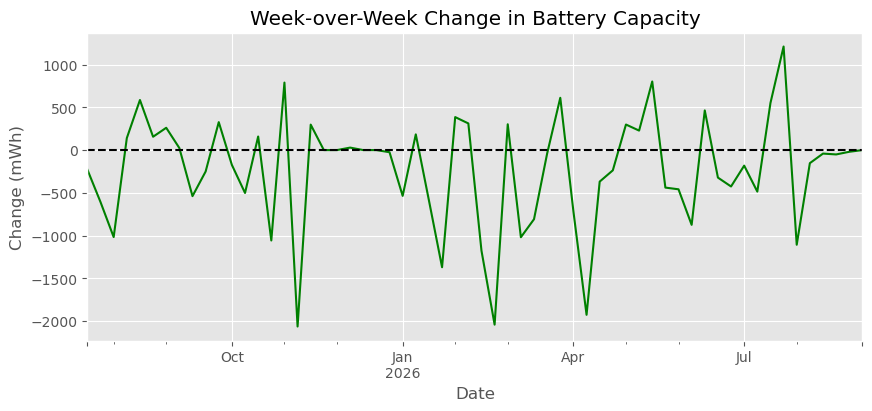

In [13]:
# Create a new column calculating the difference from the previous week
df_clean['Capacity_Change'] = df_clean['Charge Capacity'].diff()

# Drop the first row (since Week 1 has no previous week to subtract from)
df_diff = df_clean.dropna()

# Plot the week-over-week changes
df_diff['Capacity_Change'].plot(figsize=(10, 4), color='green')
plt.title('Week-over-Week Change in Battery Capacity')
plt.axhline(0, color='black', linestyle='--') # Adds a baseline at zero
plt.ylabel('Change (mWh)')
plt.show()

In [14]:

# 1. Define the ARIMA model: order=(p, d, q) -> (AR lags, differencing, MA lags)
# We feed it the original data
model = ARIMA(df_clean['Charge Capacity'], order=(1, 1, 0))

# 2. Fit the model to your data
fitted_model = model.fit()

# 3. Print the statistical summary
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:        Charge Capacity   No. Observations:                   61
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -478.250
Date:                Wed, 02 Sep 2026   AIC                            960.500
Time:                        12:25:52   BIC                            964.688
Sample:                    07-14-2025   HQIC                           962.138
                         - 09-07-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0088      0.119     -0.074      0.941      -0.242       0.225
sigma2      4.982e+05   7.27e+04      6.854      0.000    3.56e+05    6.41e+05
Ljung-Box (L1) (Q):                   0.41   Jarque-